# Agentic RAG From Scratch

This Project builds an Agentic RAG system over cricket and football documents. Unlike a linear RAG chain, the graph decides whether to retrieve, rewrites the query, grades retrieved context, retries weak searches, generates an answer, and verifies it.

**Recommended first provider: Groq.** It is fast and only requires `GROQ_API_KEY`. The configuration cell also supports Amazon Bedrock Nova Micro when AWS credentials are ready.


## IMPORTING THE LIBRARIES

In [1]:
# Imports
import json
import os
import re
from pathlib import Path
from typing import Literal, TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


## Environment and API key

```text
PROVIDER=groq
GROQ_API_KEY=gsk_...

# Optional Bedrock setup
# PROVIDER=bedrock
# AWS_REGION=us-east-1
```

Bedrock uses the standard AWS credential chain (`aws configure`, AWS profile, IAM role), not a pasted API key. Nova Micro is a good low-cost model for routing, grading, and verification.

In [2]:
# Dotenv cell
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
load_dotenv(project_root / '.env')

# Avoid failed LangSmith uploads unless the user has explicitly configured its API key.
if not os.getenv('LANGSMITH_API_KEY'):
    os.environ['LANGSMITH_TRACING'] = 'false'

PROVIDER = os.getenv('PROVIDER', 'groq').lower()
AWS_REGION = os.getenv('AWS_REGION', 'us-east-1')

if PROVIDER == 'groq':
    from langchain_groq import ChatGroq

    if not os.getenv('GROQ_API_KEY'):
        raise ValueError('Set GROQ_API_KEY in .env before running this notebook.')
    llm = ChatGroq(model='llama-3.1-8b-instant', temperature=0)
elif PROVIDER == 'bedrock':
    from langchain_aws import ChatBedrockConverse

    llm = ChatBedrockConverse(
        model_id='amazon.nova-micro-v1:0',
        region_name=AWS_REGION,
        temperature=0,
    )
else:
    raise ValueError("PROVIDER must be 'groq' or 'bedrock'.")

print(f'Using provider: {PROVIDER}')


Using provider: bedrock


## Knowledge base and RAG retriever

For clarity, this notebook uses TF-IDF plus cosine similarity. In production, replace `retrieve_documents` with an OpenSearch HNSW/cosine kNN tool; the agent graph remains unchanged.

In [3]:
DOCUMENTS = [
    {
        'source': 'Cricket rules primer',
        'content': 'The Decision Review System, or DRS, lets teams challenge selected umpire decisions. Reviews can use ball tracking, UltraEdge, and video replay. The number of available reviews depends on match format and playing conditions.',
    },
    {
        'source': 'Cricket formats primer',
        'content': 'A Twenty20 cricket innings is limited to 20 overs per side. Each over normally contains six legal deliveries. T20 strategy values rapid scoring, bowling restrictions, and field placement.',
    },
    {
        'source': 'Football Laws of the Game primer',
        'content': 'A player is in an offside position if any part of the head, body, or feet is in the opponents half and nearer the goal line than both the ball and the second-last opponent. The player commits an offence only by becoming involved in active play.',
    },
    {
        'source': 'Football VAR primer',
        'content': 'Video assistant referees review clear and obvious errors and serious missed incidents involving goals, penalty incidents, direct red cards, and mistaken identity. The referee makes the final decision.',
    },
]

vectorizer = TfidfVectorizer(stop_words='english')
document_matrix = vectorizer.fit_transform([doc['content'] for doc in DOCUMENTS])

def retrieve_documents(query: str, limit: int = 3) -> list[dict]:
    """A callable RAG tool. The graph invokes it only when routing selects retrieval."""
    query_vector = vectorizer.transform([query])
    scores = cosine_similarity(query_vector, document_matrix).flatten()
    ranked_indices = scores.argsort()[::-1][:limit]
    return [
        {**DOCUMENTS[index], 'score': round(float(scores[index]), 3)}
        for index in ranked_indices
        if scores[index] > 0
    ]


## State definition

This object flows through every node. The first seven fields are the core Agentic RAG state requested for this workflow.

In [4]:
class AgentState(TypedDict, total=False):
    question: str
    rewritten_query: str
    retrieved_docs: list[dict]
    relevance_grade: Literal['pass', 'fail']
    retry_count: int
    draft_answer: str
    final_answer: str

    # Additional control fields for the autonomous graph.
    needs_retrieval: bool
    low_confidence: bool
    verification_retry_count: int
    verification_feedback: str

MAX_RETRIEVAL_RETRIES = 2
MAX_VERIFICATION_RETRIES = 1


## Agent functions

Each function is a graph node. The LLM is used for decisions and language work; retrieval remains a tool the router can choose to call.

In [5]:
def invoke_json(prompt: str, fallback: dict) -> dict:
    """Parse a JSON-only decision response without failing the entire graph."""
    text = llm.invoke(prompt).content
    if isinstance(text, list):
        text = ''.join(str(part) for part in text)
    match = re.search(r'\{.*\}', str(text), re.DOTALL)
    if not match:
        return fallback
    try:
        return json.loads(match.group())
    except json.JSONDecodeError:
        return fallback

def format_context(documents: list[dict]) -> str:
    return '\n\n'.join(f"[{doc['source']}] {doc['content']}" for doc in documents)

def router(state: AgentState) -> dict:
    decision = invoke_json(
        'Decide if the question needs the external sports knowledge base. Greetings and thanks do not. '
        'Return JSON only: {"needs_retrieval": true or false}.\n'
        f"QUESTION: {state['question']}",
        {'needs_retrieval': True},
    )
    return {'needs_retrieval': bool(decision.get('needs_retrieval', True)), 'retry_count': 0}

def rewrite_query(state: AgentState) -> dict:
    response = llm.invoke(
        'Rewrite this into a concise retrieval query. Resolve vague wording and keep sports terms. '
        'Return only the query.\n'
        f"QUESTION: {state['question']}"
    ).content
    return {'rewritten_query': str(response).strip()}

def retrieve(state: AgentState) -> dict:
    return {'retrieved_docs': retrieve_documents(state['rewritten_query'])}

def grade_relevance(state: AgentState) -> dict:
    decision = invoke_json(
        'Decide whether CONTEXT is relevant enough to answer QUESTION. Return JSON only: '
        '{"grade": "pass" or "fail"}.\n'
        f"QUESTION: {state['question']}\nCONTEXT:\n{format_context(state['retrieved_docs'])}",
        {'grade': 'fail'},
    )
    grade = decision.get('grade', 'fail')
    return {'relevance_grade': grade if grade in {'pass', 'fail'} else 'fail'}

def reformulate_query(state: AgentState) -> dict:
    response = llm.invoke(
        'The following search was not relevant. Write one alternate retrieval query using different sports terminology. '
        'Return only the query.\n'
        f"QUESTION: {state['question']}\nFAILED QUERY: {state['rewritten_query']}"
    ).content
    return {
        'rewritten_query': str(response).strip(),
        'retry_count': state['retry_count'] + 1,
    }

def generate_answer(state: AgentState) -> dict:
    context = format_context(state.get('retrieved_docs', []))
    feedback = state.get('verification_feedback', '')
    answer = llm.invoke(
        'Answer only from CONTEXT. State when the context cannot support an answer. Cite source names in square brackets. '
        f"Verification feedback: {feedback}\nCONTEXT:\n{context}\nQUESTION: {state['question']}"
    ).content
    return {'draft_answer': str(answer).strip()}

def verify_answer(state: AgentState) -> dict:
    decision = invoke_json(
        'Check if ANSWER is supported only by CONTEXT. Return JSON only: '
        '{"supported": true or false, "feedback": "short instruction"}.\n'
        f"CONTEXT:\n{format_context(state.get('retrieved_docs', []))}\nANSWER: {state['draft_answer']}",
        {'supported': False, 'feedback': 'Use only supplied context.'},
    )
    return {
        'final_answer': state['draft_answer'],
        'low_confidence': not bool(decision.get('supported', False)),
        'verification_feedback': decision.get('feedback', ''),
        'verification_retry_count': state.get('verification_retry_count', 0) + 1,
    }

def direct_response(_: AgentState) -> dict:
    return {'final_answer': 'Hello. Ask me a question about the cricket and football knowledge base.', 'low_confidence': False}


## Conditional logic and graph

The conditional edges make this agentic: relevance failure loops through a reformulated query and failed verification regenerates with a stricter instruction.

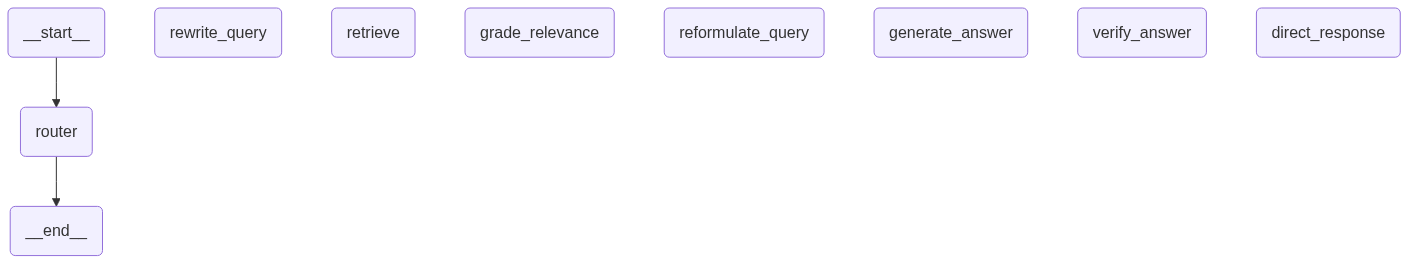

In [6]:
def route_after_router(state: AgentState) -> str:
    return 'rewrite_query' if state['needs_retrieval'] else 'direct_response'

def route_after_grading(state: AgentState) -> str:
    if state['relevance_grade'] == 'pass':
        return 'generate_answer'
    if state['retry_count'] < MAX_RETRIEVAL_RETRIES:
        return 'reformulate_query'
    return 'generate_answer'  # Stops retrieval loops and returns a low-confidence answer.

def route_after_verification(state: AgentState) -> str:
    if state['low_confidence'] and state['verification_retry_count'] <= MAX_VERIFICATION_RETRIES:
        return 'generate_answer'
    return END

graph = StateGraph(AgentState)
graph.add_node('router', router)
graph.add_node('rewrite_query', rewrite_query)
graph.add_node('retrieve', retrieve)
graph.add_node('grade_relevance', grade_relevance)
graph.add_node('reformulate_query', reformulate_query)
graph.add_node('generate_answer', generate_answer)
graph.add_node('verify_answer', verify_answer)
graph.add_node('direct_response', direct_response)

graph.add_edge(START, 'router')
graph.add_conditional_edges('router', route_after_router)
graph.add_edge('rewrite_query', 'retrieve')
graph.add_edge('retrieve', 'grade_relevance')
graph.add_conditional_edges('grade_relevance', route_after_grading)
graph.add_edge('reformulate_query', 'retrieve')
graph.add_edge('generate_answer', 'verify_answer')
graph.add_conditional_edges('verify_answer', route_after_verification)
graph.add_edge('direct_response', END)
agentic_rag = graph.compile()

try:
    display(Image(agentic_rag.get_graph().draw_mermaid_png()))
except Exception as error:
    # Mermaid text still makes the graph inspectable if image rendering is unavailable.
    print(f'Graph image could not be rendered: {error}')
    print(agentic_rag.get_graph().draw_mermaid())


## Test the Agentic RAG system

In [7]:
result = agentic_rag.invoke({
    'question': 'When is a football player offside?',
    'verification_retry_count': 0,
})

print('Answer:\n', result['final_answer'])
print('\nRetrieved sources:', [doc['source'] for doc in result.get('retrieved_docs', [])])
print('Retrieval retries:', result.get('retry_count', 0))
print('Low confidence:', result.get('low_confidence', False))


Answer:
 A football player is offside when any part of the head, body, or feet is in the opponents half and nearer the goal line than both the ball and the second-last opponent, provided that the player becomes involved in active play. [Football Laws of the Game primer]

Retrieved sources: ['Football Laws of the Game primer']
Retrieval retries: 0
Low confidence: False


## Optional tests

Use streaming to inspect which nodes execute. Run it with a greeting to confirm the router skips retrieval, then try an ambiguous sports question and inspect whether query reformulation occurs.

In [8]:
# Greeting: should execute router -> direct_response only.
greeting = agentic_rag.invoke({'question': 'hello', 'verification_retry_count': 0})
print(greeting['final_answer'])

# Inspect node-by-node state for an intentionally broad question.
for update in agentic_rag.stream(
    {'question': 'Explain the rule about being ahead of defenders', 'verification_retry_count': 0},
    stream_mode='updates',
):
    print(update)

Hello. Ask me a question about the cricket and football knowledge base.
{'router': {'needs_retrieval': True, 'retry_count': 0}}
{'rewrite_query': {'rewritten_query': '"Explain the offside rule in soccer."'}}
{'retrieve': {'retrieved_docs': [{'source': 'Football Laws of the Game primer', 'content': 'A player is in an offside position if any part of the head, body, or feet is in the opponents half and nearer the goal line than both the ball and the second-last opponent. The player commits an offence only by becoming involved in active play.', 'score': 0.215}]}}
{'grade_relevance': {'relevance_grade': 'fail'}}
{'reformulate_query': {'rewritten_query': '"Explain the concept of being ahead of the last defender in basketball."', 'retry_count': 1}}
{'retrieve': {'retrieved_docs': []}}
{'grade_relevance': {'relevance_grade': 'fail'}}
{'reformulate_query': {'rewritten_query': '"Explain the concept of being in a man-down situation in soccer."', 'retry_count': 2}}
{'retrieve': {'retrieved_docs': 